<a href="https://colab.research.google.com/github/IvanMorsin/Forecasting-electrical-power-in-multi-storey-residential-buildings/blob/main/notebook_16_%D0%9A%D0%B2%D0%B0%D0%BD%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaleido==0.2.1 -q
!pip install workalendar -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 48.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.preprocessing import MinMaxScaler
import joblib
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from workalendar.europe import Russia
from tqdm import tqdm

In [3]:
HORIZONS = {
    '4h':  8,
    '8h':  16,
    '24h': 48,
    '7d':  336,
    '14d': 672,
    '1m':  1488,
}

In [4]:
QUANTILES = [0.1, 0.5, 0.9, 0.95]

In [5]:
HOUSE_META = {
    'house_1': {'n_flats': 383, 'n_floors': 12, 'r_ud': 1.2777},
    'house_2': {'n_flats': 191, 'n_floors': 12, 'r_ud': 1.3726},
    'house_3': {'n_flats': 124, 'n_floors': 12, 'r_ud': 1.4664},
    'house_4': {'n_flats': 263, 'n_floors': 12, 'r_ud': 1.3317},
    'house_5': {'n_flats': 127, 'n_floors':  7, 'r_ud': 1.4622},
    'house_6': {'n_flats': 497, 'n_floors': 25, 'r_ud': 1.2506},
    'house_7': {'n_flats': 471, 'n_floors': 17, 'r_ud': 1.2558},
    'house_8': {'n_flats': 171, 'n_floors': 23, 'r_ud': 1.4006},
}

In [6]:
HOUSES = list(HOUSE_META.keys())

In [8]:
df = pd.read_csv('df_final+whether.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

cal = Russia()
def is_holiday(dt):
    if dt.weekday() >= 5:
        return 0
    return int(not cal.is_working_day(dt.date()))

df['is_holiday'] = df['timestamp'].apply(is_holiday)

meta_main = joblib.load("model_meta.pkl")
scalers = meta_main["scalers"]
feature_cols = meta_main["feature_cols"]

p_calc = {h: m['r_ud'] * m['n_flats'] * 1.05 for h, m in HOUSE_META.items()}

p_calc_df = pd.DataFrame([
    {'Дом': h, 'Квартир': HOUSE_META[h]['n_flats'],
     'Руд': HOUSE_META[h]['r_ud'], 'P_расч (кВт)': round(v, 1)}
    for h, v in p_calc.items()
])
print(p_calc_df.to_string(index=False))

    Дом  Квартир    Руд  P_расч (кВт)
house_1      383 1.2777         513.8
house_2      191 1.3726         275.3
house_3      124 1.4664         190.9
house_4      263 1.3317         367.7
house_5      127 1.4622         195.0
house_6      497 1.2506         652.6
house_7      471 1.2558         621.1
house_8      171 1.4006         251.5


In [9]:
def make_features_all(df):
    frames = []
    for house, meta in HOUSE_META.items():
        data = df[["timestamp", house]].copy()
        data = data.rename(columns={house: "power"})

        # нормализация через скейлер основной модели
        data["power"] = scalers[house].transform(data[["power"]]).flatten()

        data["hour"] = data["timestamp"].dt.hour
        data["minute"] = data["timestamp"].dt.minute
        data["weekday"] = data["timestamp"].dt.weekday
        data["month"] = data["timestamp"].dt.month
        data["day_of_year"] = data["timestamp"].dt.dayofyear
        data["is_weekend"] = (data["weekday"] >= 5).astype(int)
        data["is_holiday"] = df["is_holiday"].values

        for lag in [1, 2, 48, 96, 336, 672, 1488]:
            data[f"lag_{lag}"] = data["power"].shift(lag)

        data["rolling_mean_48"] = data["power"].shift(1).rolling(48).mean()
        data["rolling_mean_336"] = data["power"].shift(1).rolling(336).mean()
        data["rolling_mean_672"] = data["power"].shift(1).rolling(672).mean()
        data["rolling_mean_1488"] = data["power"].shift(1).rolling(1488).mean()

        data["temp_c"] = df["temp_c"].values
        data["humidity"] = df["humidity"].values
        data["cloudiness"] = df["cloudiness"].values

        data["n_flats"] = meta["n_flats"]
        data["n_floors"] = meta["n_floors"]

        data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
        data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

        data["week_of_year"] = data["timestamp"].dt.isocalendar().week
        max_week = 52.0
        data["week_norm"] = (data["week_of_year"] - 1) / max_week
        data["week_sin"] = np.sin(2 * np.pi * data["week_norm"])
        data["week_cos"] = np.cos(2 * np.pi * data["week_norm"])

        data["house_id"] = house
        frames.append(data)

    df_all = pd.concat(frames, ignore_index=True)
    df_all = df_all.sort_values(["timestamp", "house_id"]).reset_index(drop=True)
    df_all = df_all.dropna().reset_index(drop=True)
    return df_all

df_long = make_features_all(df)

feature_cols = [c for c in df_long.columns
                if c not in ['timestamp', 'power', 'house_id']]

In [10]:
def make_features(df, house, lag_features=[1, 2, 48, 96, 336]):
    data = df[['timestamp', house]].copy()

    data['hour'] = data['timestamp'].dt.hour
    data['minute'] = data['timestamp'].dt.minute
    data['weekday'] = data['timestamp'].dt.weekday
    data['month'] = data['timestamp'].dt.month
    data['day_of_year'] = data['timestamp'].dt.dayofyear
    data['is_weekend'] = (data['weekday'] >= 5).astype(int)
    data['is_holiday'] = df['is_holiday'].values

    for lag in lag_features:
        data[f'lag_{lag}'] = data[house].shift(lag)

    data['rolling_mean_48'] = data[house].shift(1).rolling(48).mean()
    data['rolling_mean_336'] = data[house].shift(1).rolling(336).mean()

    data['temp_c'] = df['temp_c'].values
    data['humidity'] = df['humidity'].values
    data['cloudiness'] = df['cloudiness'].values

    data = data.dropna().reset_index(drop=True)
    feature_cols = [c for c in data.columns if c not in ['timestamp', house]]

    return data[feature_cols], data[house], data['timestamp']

X_check, y_check, _ = make_features(df, 'house_1')
print(f'Признаков: {X_check.shape[1]}')
print(f'Строк: {X_check.shape[0]}')
print(f'Список: {X_check.columns.tolist()}')

Признаков: 17
Строк: 35924
Список: ['hour', 'minute', 'weekday', 'month', 'day_of_year', 'is_weekend', 'is_holiday', 'lag_1', 'lag_2', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_48', 'rolling_mean_336', 'temp_c', 'humidity', 'cloudiness']


In [11]:
def pinball_loss(y_true, y_pred, alpha):
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, alpha * err, (alpha - 1) * err))

def coverage(y_true, q_low, q_high):
    return np.mean((y_true >= q_low) & (y_true <= q_high)) * 100

def conformal_correction(y_val, pred_val_low, pred_val_high, coverage_target=0.80):
    scores = np.maximum(pred_val_low - y_val, y_val - pred_val_high)
    return np.quantile(scores, coverage_target)

def inverse_power(house, values):
    #Обратное преобразование нормализованных значений в кВт
    return scalers[house].inverse_transform(
        np.array(values).reshape(-1, 1)
    ).flatten()

In [12]:
os.makedirs("models_ev", exist_ok=True)

results = {}
results_conformal = {}

for hz_name, hz_steps in tqdm(HORIZONS.items(), desc="Квантильные модели"):
    print(f"\nГоризонт {hz_name}")

    frames_shifted = []
    for house in HOUSES:
        df_h = df_long[df_long["house_id"] == house].copy()
        df_h["power_target"] = df_h["power"].shift(-hz_steps)
        frames_shifted.append(df_h)

    df_shifted = pd.concat(frames_shifted, ignore_index=True)
    df_shifted = df_shifted.dropna(subset=["power_target"]).reset_index(drop=True)
    ts_shifted = df_shifted["timestamp"]

    split_train_h = pd.Timestamp(
        np.quantile(ts_shifted.astype(np.int64), 0.70)
    )
    split_val_h = pd.Timestamp(
        np.quantile(ts_shifted.astype(np.int64), 0.85)
    )

    mask_tr = ts_shifted <= split_train_h
    mask_val = (ts_shifted > split_train_h) & (ts_shifted <= split_val_h)
    mask_te = ts_shifted > split_val_h

    X_train = df_shifted.loc[mask_tr, feature_cols]
    y_train = df_shifted.loc[mask_tr, "power_target"]
    X_val = df_shifted.loc[mask_val, feature_cols]
    y_val = df_shifted.loc[mask_val, "power_target"]
    X_test = df_shifted.loc[mask_te, feature_cols]
    y_test = df_shifted.loc[mask_te, "power_target"]
    ts_test = df_shifted.loc[mask_te, "timestamp"]
    house_test = df_shifted.loc[mask_te, "house_id"]

    print(f"  train={len(X_train)} val={len(X_val)} test={len(X_test)}")

    models = {}
    for alpha in QUANTILES:
        model = lgb.LGBMRegressor(
            objective="quantile",
            alpha=alpha,
            metric="quantile",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )
        models[alpha] = model
        joblib.dump(model, f"models_ev/lgbm_{hz_name}_q{int(alpha * 100)}.pkl")
        print(f"  α={alpha:.2f} best_iter={model.best_iteration_}")

    # предсказания в нормализованном пространстве - обратное преобразование
    preds_test_norm = {alpha: model.predict(X_test) for alpha, model in models.items()}

    # inverse_transform для каждого дома
    preds_test = {}
    for alpha in QUANTILES:
        pred_orig = np.zeros(len(y_test))
        for house in HOUSES:
            mask_h = house_test.values == house
            pred_orig[mask_h] = inverse_power(house, preds_test_norm[alpha][mask_h])
        preds_test[alpha] = pred_orig

    # y_test тоже в оригинальный масштаб
    y_test_orig = np.zeros(len(y_test))
    for house in HOUSES:
        mask_h = house_test.values == house
        y_test_orig[mask_h] = inverse_power(house, y_test.values[mask_h])

    results[hz_name] = {
        "models": models,
        "preds": preds_test,
        "y_test": y_test_orig,
        "ts_test": ts_test.values,
        "house_test": house_test.values,
    }

    # конформная калибровка - на val в оригинальном масштабе
    y_val_orig = np.zeros(len(y_val))
    pred_val = {alpha: np.zeros(len(y_val)) for alpha in QUANTILES}
    house_val = df_shifted.loc[mask_val, "house_id"]

    for house in HOUSES:
        mask_h = house_val.values == house
        y_val_orig[mask_h] = inverse_power(house, y_val.values[mask_h])
        for alpha in QUANTILES:
            pred_val[alpha][mask_h] = inverse_power(
                house, models[alpha].predict(X_val)[mask_h]
            )

    q_corr_80 = conformal_correction(
        y_val_orig, pred_val[0.1], pred_val[0.9], 0.80
    )
    q_corr_85 = conformal_correction(
        y_val_orig, pred_val[0.1], pred_val[0.95], 0.85
    )

    results_conformal[hz_name] = {
        "y_test": y_test_orig,
        "ts_test": ts_test.values,
        "house_test": house_test.values,
        "q10": preds_test[0.1],
        "q50": preds_test[0.5],
        "q90": preds_test[0.9],
        "q95": preds_test[0.95],
        "q90_conf": preds_test[0.9] + q_corr_80,
        "q10_conf": preds_test[0.1] - q_corr_80,
        "q95_conf": preds_test[0.95] + q_corr_85,
        "q_corr_80": round(q_corr_80, 3),
        "q_corr_85": round(q_corr_85, 3),
    }
    print(f"  q_corr_80={q_corr_80:.2f} кВт  q_corr_85={q_corr_85:.2f} кВт")

Квантильные модели:   0%|          | 0/6 [00:00<?, ?it/s]


Горизонт 4h
  train=194680 val=41720 test=41712
  α=0.10 best_iter=499
  α=0.50 best_iter=500
  α=0.90 best_iter=500
  α=0.95 best_iter=488


Квантильные модели:  17%|█▋        | 1/6 [02:07<10:38, 127.69s/it]

  q_corr_80=0.31 кВт  q_corr_85=0.35 кВт

Горизонт 8h
  train=194640 val=41704 test=41704
  α=0.10 best_iter=493
  α=0.50 best_iter=500
  α=0.90 best_iter=474
  α=0.95 best_iter=496


Квантильные модели:  33%|███▎      | 2/6 [04:02<08:00, 120.13s/it]

...

  q_corr_80=0.21 кВт  q_corr_85=0.31 кВт

Горизонт 14d
  train=190960 val=40920 test=40920
  α=0.10 best_iter=107
  α=0.50 best_iter=112
  α=0.90 best_iter=152
  α=0.95 best_iter=136


Квантильные модели:  83%|████████▎ | 5/6 [07:16<01:10, 70.06s/it]

  q_corr_80=0.40 кВт  q_corr_85=0.40 кВт

Горизонт 1m
  train=186392 val=39944 test=39936
  α=0.10 best_iter=346
  α=0.50 best_iter=446
  α=0.90 best_iter=149
  α=0.95 best_iter=141


Квантильные модели: 100%|██████████| 6/6 [08:28<00:00, 84.80s/it]

  q_corr_80=0.65 кВт  q_corr_85=0.71 кВт


In [13]:
#метрики
metrics_rows = []

for hz_name in HORIZONS:
    r = results[hz_name]

    for house in HOUSES:
        mask_h = r["house_test"] == house
        y_h = r["y_test"][mask_h]

        if len(y_h) == 0:
            continue

        row = {"house": house, "horizon": hz_name}
        for alpha in QUANTILES:
            row[f"pinball_{alpha}"] = round(
                pinball_loss(y_h, r["preds"][alpha][mask_h], alpha), 4
            )

        mape = np.mean(
            np.abs((y_h - r["preds"][0.5][mask_h]) / (np.abs(y_h) + 1e-8))
        ) * 100
        row["mape_q50"] = round(mape, 3)
        row["coverage_80pct"] = round(
            coverage(y_h, r["preds"][0.1][mask_h], r["preds"][0.9][mask_h]), 1
        )
        row["coverage_85pct"] = round(
            coverage(y_h, r["preds"][0.1][mask_h], r["preds"][0.95][mask_h]), 1
        )
        metrics_rows.append(row)

df_metrics = pd.DataFrame(metrics_rows)

mape_pivot = df_metrics.pivot(index="house", columns="horizon", values="mape_q50")
mape_pivot = mape_pivot[list(HORIZONS.keys())]
mape_pivot.loc["Среднее"] = mape_pivot.mean()
print("MAPE Q0.5 (медианный прогноз), %:")
print(mape_pivot.round(2).to_string())

df_metrics.to_csv("results_quantile_metrics.csv", index=False)

MAPE Q0.5 (медианный прогноз), %:
horizon    4h    8h   24h    7d   14d    1m
house                                      
house_1  5.54  5.41  5.32  6.33  6.78  6.78
house_2  6.82  6.90  7.18  7.87  8.07  8.14
house_3  7.12  7.17  7.44  8.27  8.33  8.16
house_4  6.19  6.09  6.25  6.80  7.10  7.56
house_5  7.24  7.43  7.77  9.24  9.94  9.02
house_6  5.02  5.27  4.78  5.87  6.20  7.84
house_7  4.89  4.79  4.44  4.81  4.98  5.03
house_8  5.27  5.38  5.32  6.50  6.66  7.07
Среднее  6.01  6.05  6.06  6.96  7.26  7.45


In [14]:
conf_rows = []

for hz_name in HORIZONS:
    r = results_conformal[hz_name]

    for house in HOUSES:
        mask_h = r["house_test"] == house
        y_h = r["y_test"][mask_h]

        if len(y_h) == 0:
            continue

        conf_rows.append({
            "house": house,
            "horizon": hz_name,
            "cov_80_before": round(
                coverage(y_h, r["q10"][mask_h], r["q90"][mask_h]), 1
            ),
            "cov_80_after": round(
                coverage(y_h, r["q10_conf"][mask_h], r["q90_conf"][mask_h]), 1
            ),
            "cov_85_before": round(
                coverage(y_h, r["q10"][mask_h], r["q95"][mask_h]), 1
            ),
            "cov_85_after": round(
                coverage(y_h, r["q10_conf"][mask_h], r["q95_conf"][mask_h]), 1
            ),
        })

df_conf = pd.DataFrame(conf_rows)

for col_before, col_after, target in [
    ("cov_80_before", "cov_80_after", 80),
    ("cov_85_before", "cov_85_after", 85),
]:
    pivot_before = df_conf.pivot(
        index="house", columns="horizon", values=col_before
    )[list(HORIZONS.keys())]
    pivot_after = df_conf.pivot(
        index="house", columns="horizon", values=col_after
    )[list(HORIZONS.keys())]
    pivot_before.loc["Среднее"] = pivot_before.mean()
    pivot_after.loc["Среднее"] = pivot_after.mean()

    print(f"\nПокрытие {target}% - До поправки:")
    print(pivot_before.round(1).to_string())
    print(f"\nПокрытие {target}% - После поправки:")
    print(pivot_after.round(1).to_string())


Покрытие 80% — До поправки:
horizon    4h    8h   24h    7d   14d    1m
house                                      
house_1  74.2  72.7  75.7  79.9  81.2  73.4
house_2  75.7  75.8  75.3  78.1  80.4  73.9
house_3  78.7  79.1  78.5  79.4  80.8  78.1
house_4  74.9  74.6  74.6  75.4  74.7  70.3
house_5  74.5  72.9  74.3  70.0  68.3  70.1
house_6  78.6  78.3  77.9  79.1  78.4  75.1
house_7  73.8  78.8  76.9  82.0  84.5  80.8
house_8  76.8  75.1  76.4  72.7  73.8  70.9
Среднее  75.9  75.9  76.2  77.1  77.8  74.1

Покрытие 80% — После поправки:
horizon    4h    8h   24h    7d   14d    1m
house                                      
house_1  77.6  76.6  79.2  81.9  84.5  80.0
house_2  82.6  82.0  80.7  82.0  86.4  84.2
house_3  86.4  87.4  84.1  84.0  88.7  90.4
house_4  79.9  79.5  78.5  78.3  80.8  78.5
house_5  80.9  79.1  79.5  74.2  75.8  81.0
house_6  80.8  80.2  79.7  80.3  80.7  78.9
house_7  76.3  81.2  79.2  83.7  86.7  84.8
house_8  81.7  80.7  80.6  75.8  79.2  79.1
Среднее  80.8  

In [15]:
# доступная мощность
# загрузка ВВУ зима/лето - берём val + test чтобы захватить все сезоны
load_rows = []

for house in HOUSES:
    p_r = p_calc[house]

    # собираем val и test из всех горизонтов для полного охвата сезонов
    all_ts = []
    all_y = []
    for hz_name in HORIZONS:
        r = results[hz_name]
        mask_h = r["house_test"] == house
        all_ts.extend(pd.to_datetime(r["ts_test"][mask_h]).tolist())
        all_y.extend(r["y_test"][mask_h].tolist())

    df_h = pd.DataFrame({"timestamp": all_ts, "power": all_y})
    df_h = df_h.drop_duplicates("timestamp").sort_values("timestamp")
    df_h["date"] = df_h["timestamp"].dt.date
    df_h["month"] = df_h["timestamp"].dt.month

    daily_max = df_h.groupby("date")["power"].max()

    winter_dates = df_h[df_h["month"].isin([12, 1, 2])]["date"].unique()
    summer_dates = df_h[df_h["month"].isin([6, 7, 8])]["date"].unique()

    winter_max = daily_max[daily_max.index.isin(winter_dates)].max() \
        if len(winter_dates) > 0 else np.nan
    summer_min = daily_max[daily_max.index.isin(summer_dates)].min() \
        if len(summer_dates) > 0 else np.nan

    load_rows.append({
        "Дом": house,
        "P_расч (кВт)": round(p_r, 1),
        "Зимний макс. (кВт)": round(winter_max, 1) if not np.isnan(winter_max) else np.nan,
        "Загрузка зима (%)": round(winter_max / p_r * 100, 1) if not np.isnan(winter_max) else np.nan,
        "Летний мин. (кВт)": round(summer_min, 1) if not np.isnan(summer_min) else np.nan,
        "Загрузка лето (%)": round(summer_min / p_r * 100, 1) if not np.isnan(summer_min) else np.nan,
        "Резерв зима (кВт)": round(p_r - winter_max, 1) if not np.isnan(winter_max) else np.nan,
        "Резерв лето (кВт)": round(p_r - summer_min, 1) if not np.isnan(summer_min) else np.nan,
    })

df_load = pd.DataFrame(load_rows)
print(df_load.to_string(index=False))
df_load.to_csv("results_load_factor.csv", index=False)

    Дом  P_расч (кВт)  Зимний макс. (кВт)  Загрузка зима (%)  Летний мин. (кВт)  Загрузка лето (%)  Резерв зима (кВт)  Резерв лето (кВт)
house_1         513.8               101.5               19.7               63.5               12.4              412.4              450.3
house_2         275.3                43.5               15.8               28.5               10.3              231.8              246.8
house_3         190.9                30.8               16.2               17.7                9.3              160.1              173.2
house_4         367.7                71.6               19.5               41.6               11.3              296.1              326.1
house_5         195.0                48.7               25.0               26.4               13.5              146.3              168.6
house_6         652.6               154.1               23.6               88.0               13.5              498.5              564.7
house_7         621.1               161.5

In [23]:
# Суточный график
profile_rows = []

for house in HOUSES:
    r = results_conformal['24h']
    mask_h = r['house_test'] == house
    ts = pd.to_datetime(r['ts_test'][mask_h])
    p_r = p_calc[house]

    q90_conf = r['q90_conf'][mask_h]
    p_avail  = p_r - q90_conf

    df_profile = pd.DataFrame({'hour': ts.hour, 'p_avail': p_avail})
    hourly = df_profile.groupby('hour')['p_avail'].mean()

    for hour, val in hourly.items():
        profile_rows.append({
            'house': house, 'hour': hour, 'P_avail': round(val, 1)
        })

df_profile_hourly = pd.DataFrame(profile_rows)

fig2 = go.Figure()
for house in HOUSES:
    subset = df_profile_hourly[df_profile_hourly["house"] == house]
    fig2.add_trace(go.Scatter(
        x=[f"{h:02d}:00" for h in subset["hour"]],
        y=subset["P_avail"],
        mode="lines+markers",
        name=house,
        line=dict(width=1.5),
        marker=dict(size=4),
    ))

fig2.update_layout(
    title=dict(
        text="Суточный график доступной мощности по домам, кВт.<br>"
             "Сценарий Q0.9_conf | Горизонт 24h",
        font=dict(size=12),
    ),
    xaxis_title="Час суток",
    yaxis_title="Доступная мощность, кВт",
    hovermode="x unified",
    template="plotly_white",
    height=500,
    width=750,
    margin=dict(l=60, r=30, t=80, b=60),
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02,
        font=dict(size=10),
    ),
)
fig2.show()
fig2.write_image("nb15_daily_profile.png", scale=2)

In [17]:
# загрузка ввода зима/лето
load_rows = []

for house in HOUSES:
    p_r = p_calc[house]
    r = results_conformal['24h']
    mask_h = r['house_test'] == house
    ts = pd.to_datetime(r['ts_test'][mask_h])
    y = r['y_test'][mask_h]

    df_h = pd.DataFrame({'timestamp': ts, 'power': y})
    df_h['date'] = df_h['timestamp'].dt.date
    df_h['month'] = df_h['timestamp'].dt.month

    daily_max = df_h.groupby('date')['power'].max()

    winter_dates = df_h[df_h['month'].isin([12, 1, 2])]['date'].unique()
    summer_dates = df_h[df_h['month'].isin([6, 7, 8])]['date'].unique()

    winter_max = daily_max[daily_max.index.isin(winter_dates)].max()
    summer_min = daily_max[daily_max.index.isin(summer_dates)].min()

    load_rows.append({
        'Дом':                 house,
        'P_расч (кВт)':       round(p_r, 1),
        'Зимний макс. (кВт)': round(winter_max, 1),
        'Загрузка зима (%)':  round(winter_max / p_r * 100, 1),
        'Летний мин. (кВт)':  round(summer_min, 1),
        'Загрузка лето (%)':  round(summer_min / p_r * 100, 1),
        'Резерв зима (кВт)':  round(p_r - winter_max, 1),
        'Резерв лето (кВт)':  round(p_r - summer_min, 1),
    })

df_load = pd.DataFrame(load_rows)
print(df_load.to_string(index=False))
df_load.to_csv('results_load_factor.csv', index=False)

    Дом  P_расч (кВт)  Зимний макс. (кВт)  Загрузка зима (%)  Летний мин. (кВт)  Загрузка лето (%)  Резерв зима (кВт)  Резерв лето (кВт)
house_1         513.8                95.5               18.6               63.5               12.4              418.3              450.3
house_2         275.3                41.7               15.2               27.6               10.0              233.6              247.7
house_3         190.9                28.8               15.1               17.7                9.3              162.1              173.2
house_4         367.7                64.6               17.6               41.6               11.3              303.1              326.1
house_5         195.0                44.2               22.7               26.4               13.5              150.8              168.6
house_6         652.6               147.1               22.5               88.0               13.5              505.5              564.7
house_7         621.1               156.1

In [18]:
# итоговая сводная таблица
summary_rows = []

for house in HOUSES:
    p_r = p_calc[house]
    r = results_conformal['24h']
    mask_h = r['house_test'] == house

    winter_max = df_load[df_load['Дом'] == house]['Зимний макс. (кВт)'].values[0]
    summer_min = df_load[df_load['Дом'] == house]['Летний мин. (кВт)'].values[0]

    for scenario, q_key in [('Q0.9_conf', 'q90_conf'),
                              ('Q0.95_conf', 'q95_conf')]:
        q_pred  = r[q_key][mask_h]
        p_avail = p_r - q_pred

        summary_rows.append({
            'Дом':                   house,
            'Сценарий':              scenario,
            'P_расч (кВт)':          round(p_r, 1),
            'Зима: макс нагр (кВт)': round(winter_max, 1),
            'Зима: загрузка (%)':    round(winter_max / p_r * 100, 1),
            'Зима: резерв (кВт)':    round(p_r - winter_max, 1),
            'Лето: мин нагр (кВт)':  round(summer_min, 1),
            'Лето: загрузка (%)':    round(summer_min / p_r * 100, 1),
            'Лето: резерв (кВт)':    round(p_r - summer_min, 1),
            'P_avail_min (кВт)':     round(float(np.min(p_avail)), 1),
        })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv('results_ev_capacity_final.csv', index=False)

for scenario in ['Q0.9_conf', 'Q0.95_conf']:
    subset = df_summary[df_summary['Сценарий'] == scenario].copy()
    subset.loc['Итого'] = [
        '—', scenario,
        round(subset['P_расч (кВт)'].sum(), 1),
        round(subset['Зима: макс нагр (кВт)'].sum(), 1),
        round(subset['Зима: загрузка (%)'].mean(), 1),
        round(subset['Зима: резерв (кВт)'].sum(), 1),
        round(subset['Лето: мин нагр (кВт)'].sum(), 1),
        round(subset['Лето: загрузка (%)'].mean(), 1),
        round(subset['Лето: резерв (кВт)'].sum(), 1),
        round(subset['P_avail_min (кВт)'].sum(), 1),
    ]
    print(f'\nСценарий {scenario}:')
    print(subset.to_string(index=False))


Сценарий Q0.9_conf:
    Дом  Сценарий  P_расч (кВт)  Зима: макс нагр (кВт)  Зима: загрузка (%)  Зима: резерв (кВт)  Лето: мин нагр (кВт)  Лето: загрузка (%)  Лето: резерв (кВт)  P_avail_min (кВт)
house_1 Q0.9_conf         513.8                   95.5                18.6               418.3                  63.5                12.4               450.3              399.8
house_2 Q0.9_conf         275.3                   41.7                15.1               233.6                  27.6                10.0               247.7              232.3
house_3 Q0.9_conf         190.9                   28.8                15.1               162.1                  17.7                 9.3               173.2              157.9
house_4 Q0.9_conf         367.7                   64.6                17.6               303.1                  41.6                11.3               326.1              295.0
house_5 Q0.9_conf         195.0                   44.2                22.7               150.8     

In [19]:
# Сводная по горизонтам
rows_hz = []
for house in HOUSES:
    row = {'Дом': house, 'P_расч (кВт)': round(p_calc[house], 1)}
    for hz_name in HORIZONS.keys():
        r = results_conformal[hz_name]
        mask_h = r['house_test'] == house
        p_avail = p_calc[house] - r['q90_conf'][mask_h]
        row[hz_name] = round(float(np.min(p_avail)), 1) if len(p_avail) > 0 else np.nan
    rows_hz.append(row)

df_hz = pd.DataFrame(rows_hz)
totals = {'Дом': 'Итого', 'P_расч (кВт)': round(df_hz['P_расч (кВт)'].sum(), 1)}
for hz_name in HORIZONS.keys():
    totals[hz_name] = round(df_hz[hz_name].sum(), 1)
df_hz.loc[len(df_hz)] = totals

print(df_hz.to_string(index=False))
df_hz.to_csv('results_ev_all_horizons.csv', index=False)

    Дом  P_расч (кВт)     4h     8h    24h     7d    14d     1m
house_1         513.8  402.1  401.9  399.8  409.1  407.2  405.6
house_2         275.3  232.1  232.1  232.3  232.6  232.7  232.7
house_3         190.9  158.8  159.3  157.9  160.1  160.2  159.9
house_4         367.7  296.4  294.8  295.0  297.9  298.0  296.7
house_5         195.0  145.8  146.6  145.7  146.1  145.8  145.9
house_6         652.6  504.2  503.5  503.2  508.8  509.6  506.3
house_7         621.1  452.3  450.3  454.1  453.7  455.0  454.3
house_8         251.5  188.5  189.1  190.0  190.2  191.6  190.3
  Итого        3067.9 2380.2 2377.6 2378.0 2398.5 2400.1 2391.7


In [20]:
# сохранение моделей и метаданных
conformal_thresholds = {}
for hz_name in HORIZONS.keys():
    r = results_conformal[hz_name]
    conformal_thresholds[hz_name] = {
        "q_corr_80": r["q_corr_80"],
        "q_corr_85": r["q_corr_85"],
    }
joblib.dump(conformal_thresholds, "models_ev/conformal_thresholds.pkl")

# feature_cols берём из основной модели — не из локальной переменной
meta_ev = {
    "houses": HOUSES,
    "horizons": HORIZONS,
    "house_meta": HOUSE_META,
    "p_calc": p_calc,
    "quantiles": QUANTILES,
    "feature_cols": feature_cols,  # из model_meta.pkl
    "scalers": scalers,            # из model_meta.pkl
}
joblib.dump(meta_ev, "models_ev/model_meta.pkl")

['models_ev/model_meta.pkl']

In [33]:
# выбираем репрезентативные дни по данным 4h
r_ref_4h = results_conformal["4h"]
mask_1_4h = r_ref_4h["house_test"] == "house_1"
ts_ref_4h = pd.to_datetime(r_ref_4h["ts_test"][mask_1_4h])
y_ref_4h = r_ref_4h["y_test"][mask_1_4h]

df_ref = pd.DataFrame({"timestamp": ts_ref_4h, "power": y_ref_4h})
df_ref["date"] = df_ref["timestamp"].dt.date
df_ref["month"] = df_ref["timestamp"].dt.month
df_ref["weekday"] = df_ref["timestamp"].dt.weekday

points_per_day = df_ref.groupby("date")["power"].count()
full_days = points_per_day[points_per_day >= 46].index
daily_max = df_ref.groupby("date")["power"].max()

winter_dates = df_ref[
    df_ref["month"].isin([12, 1, 2]) &
    (df_ref["weekday"] < 5) &
    df_ref["date"].isin(full_days)
]["date"].unique()

summer_dates = df_ref[
    df_ref["month"].isin([6, 7, 8]) &
    (df_ref["weekday"] < 5) &
    df_ref["date"].isin(full_days)
]["date"].unique()

winter_day = daily_max[daily_max.index.isin(winter_dates)].idxmax()
summer_day = daily_max[daily_max.index.isin(summer_dates)].idxmin()

print(f"День макс. нагрузки: {winter_day}")
print(f"День мин. нагрузки:  {summer_day}")

# строим график по данным 24h
house = "house_1"
p_r = p_calc[house]
r = results_conformal["24h"]
mask_h = r["house_test"] == house

ts = pd.to_datetime(r["ts_test"][mask_h])
y_test_plot = r["y_test"][mask_h]
q50 = r["q50"][mask_h]
q90 = r["q90_conf"][mask_h]
q10 = r["q10_conf"][mask_h]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f"День макс. нагрузки ({winter_day})",
        f"День мин. нагрузки ({summer_day})",
    ],
    horizontal_spacing=0.12,
)

for col_idx, target_date in enumerate([winter_day, summer_day], start=1):
    mask_day = np.array([x.date() == target_date for x in ts])
    ts_day = ts[mask_day].tolist()
    y_day = y_test_plot[mask_day]
    q50_day = q50[mask_day]
    q90_day = q90[mask_day]
    q10_day = q10[mask_day]
    fill_top = np.full(len(ts_day), p_r)

    # заливка доступной мощности: от Q0.9 до P_расч
    fig.add_trace(go.Scatter(
        x=ts_day + ts_day[::-1],
        y=list(fill_top) + list(q90_day[::-1]),
        fill="toself",
        fillcolor="rgba(34,139,34,0.15)",
        line=dict(color="rgba(0,0,0,0)"),
        name="Доступная мощность (Q0.9_conf)",
        showlegend=(col_idx == 1),
        hoverinfo="skip",
    ), row=1, col=col_idx)

    # интервал Q0.1-Q0.9
    fig.add_trace(go.Scatter(
        x=ts_day + ts_day[::-1],
        y=list(q90_day) + list(q10_day[::-1]),
        fill="toself",
        fillcolor="rgba(200,200,200,0.4)",
        line=dict(color="rgba(0,0,0,0)"),
        name="Интервал Q0.1–Q0.9",
        showlegend=(col_idx == 1),
        hoverinfo="skip",
    ), row=1, col=col_idx)

    # P_расч
    fig.add_trace(go.Scatter(
        x=[ts_day[0], ts_day[-1]],
        y=[p_r, p_r],
        mode="lines",
        name=f"P_расч = {p_r:.0f} кВт",
        line=dict(color="darkgreen", width=1.5, dash="dash"),
        showlegend=(col_idx == 1),
    ), row=1, col=col_idx)

    # факт
    fig.add_trace(go.Scatter(
        x=ts_day, y=y_day,
        mode="lines", name="Факт",
        line=dict(color="#1f77b4", width=2, shape="hv"),
        showlegend=(col_idx == 1),
    ), row=1, col=col_idx)

    # прогноз Q0.5
    fig.add_trace(go.Scatter(
        x=ts_day, y=q50_day,
        mode="lines", name="Прогноз Q0.5",
        line=dict(color="#d62728", width=2, shape="hv"),
        showlegend=(col_idx == 1),
    ), row=1, col=col_idx)

    # ось Y: детальные значения внизу + значение на P_расч
    y_detail_max = max(float(np.max(q90_day)), float(np.max(y_day)))
    step = 20
    detail_ticks = list(range(0, int(y_detail_max) + step, step))
    if p_r not in detail_ticks:
        tick_vals = detail_ticks + [p_r]
        tick_text = [str(v) for v in detail_ticks] + [f"{p_r:.0f}"]
    else:
        tick_vals = detail_ticks
        tick_text = [str(v) for v in detail_ticks]

    fig.update_xaxes(
        tickformat="%H:%M",
        dtick=3 * 3600000,
        title_text="Время суток",
        title_font=dict(size=10),
        tickfont=dict(size=9),
        title_standoff=15,
        row=1, col=col_idx,
    )
    fig.update_yaxes(
        range=[0, p_r * 1.05],
        tickmode="array",
        tickvals=tick_vals,
        ticktext=tick_text,
        title_text="кВт" if col_idx == 1 else "",
        title_font=dict(size=10),
        tickfont=dict(size=9),
        row=1, col=col_idx,
    )

fig.update_layout(
    title=dict(
        text=(
            f"Дом 1: квантильный прогноз нагрузки и доступная мощность<br>"
            f"P_расч = {p_r:.0f} кВт | Горизонт 24h | Сценарий Q0.9_conf"
        ),
        font=dict(size=12),
        x=0.5,
        xanchor="center",
    ),
    width=950,
    height=520,
    font=dict(size=10, family="Arial"),
    margin=dict(l=70, r=30, t=100, b=120),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.22,
        xanchor="center",
        x=0.5,
        font=dict(size=10),
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgrey",
        borderwidth=1,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.show()
fig.write_image("nb15_house1_winter_summer.png", scale=2)

День макс. нагрузки: 2019-12-04
День мин. нагрузки:  2019-08-23


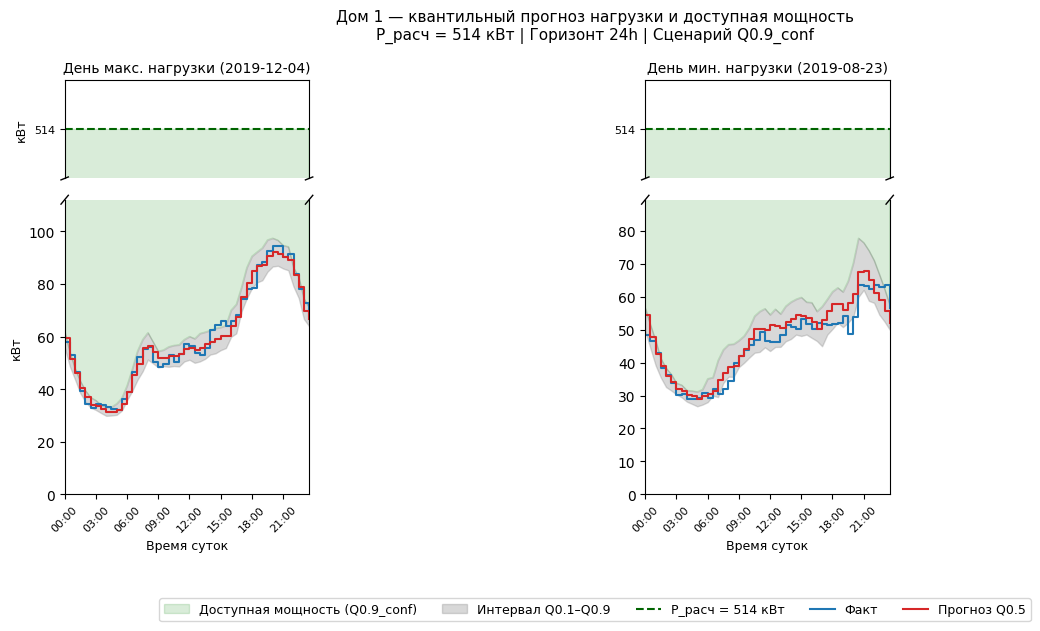

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6),
    gridspec_kw={"height_ratios": [1, 3]},
)

# верхняя часть — узкая полоса у P_расч
# нижняя часть — детальная область нагрузки
for col_idx, (target_date, ax_top, ax_bot) in enumerate(
    zip(
        [winter_day, summer_day],
        [axes[0, 0], axes[0, 2]],
        [axes[1, 0], axes[1, 2]],
    )
):
    mask_day = np.array([x.date() == target_date for x in ts])
    ts_day = ts[mask_day]
    y_day = y_test_plot[mask_day]
    q50_day = q50[mask_day]
    q90_day = q90[mask_day]
    q10_day = q10[mask_day]

    x_num = np.arange(len(ts_day))
    x_labels = [t.strftime("%H:%M") for t in ts_day]

    y_detail_max = max(float(np.max(q90_day)), float(np.max(y_day))) * 1.15
    y_break_low = y_detail_max       # нижняя граница разрыва
    y_break_high = p_r * 0.97        # верхняя граница разрыва

    for ax, (y_min, y_max) in zip(
        [ax_top, ax_bot],
        [(y_break_high, p_r * 1.03), (0, y_break_low)],
    ):
        # заливка доступной мощности
        ax.fill_between(
            x_num, q90_day, p_r,
            alpha=0.15, color="green",
            label="Доступная мощность (Q0.9_conf)" if col_idx == 0 else "",
        )
        # интервал
        ax.fill_between(
            x_num, q10_day, q90_day,
            alpha=0.3, color="grey",
            label="Интервал Q0.1–Q0.9" if col_idx == 0 else "",
        )
        # P_расч
        ax.axhline(
            p_r, color="darkgreen", linewidth=1.5,
            linestyle="--",
            label=f"P_расч = {p_r:.0f} кВт" if col_idx == 0 else "",
        )
        # факт
        ax.step(x_num, y_day, where="post", color="#1f77b4",
                linewidth=1.5,
                label="Факт" if col_idx == 0 else "")
        # прогноз Q0.5
        ax.step(x_num, q50_day, where="post", color="#d62728",
                linewidth=1.5,
                label="Прогноз Q0.5" if col_idx == 0 else "")

        ax.set_ylim(y_min, y_max)
        ax.set_xlim(0, len(x_num) - 1)

        if ax == ax_bot:
            tick_step = max(1, len(x_num) // 8)
            ax.set_xticks(x_num[::tick_step])
            ax.set_xticklabels(x_labels[::tick_step], rotation=45, fontsize=8)
            ax.set_xlabel("Время суток", fontsize=9)
        else:
            ax.set_xticks([])
            ax.set_yticks([p_r])
            ax.set_yticklabels([f"{p_r:.0f}"], fontsize=8)

        if col_idx == 0:
            ax.set_ylabel("кВт", fontsize=9)

        ax.spines["bottom" if ax == ax_top else "top"].set_visible(False)
        ax.tick_params(
            bottom=(ax == ax_bot),
            top=(ax == ax_top),
            labelbottom=(ax == ax_bot),
        )

        # знаки разрыва
        d = 0.015
        kwargs = dict(transform=ax.transAxes, color="k",
                      clip_on=False, linewidth=1)
        if ax == ax_top:
            ax.plot((-d, +d), (-d, +d), **kwargs)
            ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        else:
            ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    ax_top.set_title(
        f"{'День макс. нагрузки' if col_idx == 0 else 'День мин. нагрузки'}"
        f" ({target_date})",
        fontsize=10,
    )

# убираем пустые оси (col 1 и 3 — разделители)
for ax in [axes[0, 1], axes[1, 1], axes[0, 3], axes[1, 3]]:
    ax.set_visible(False)

# легенда
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=5,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05),
    framealpha=0.8,
)

fig.suptitle(
    f"Дом 1 — квантильный прогноз нагрузки и доступная мощность\n"
    f"P_расч = {p_r:.0f} кВт | Горизонт 24h | Сценарий Q0.9_conf",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("nb15_house1_winter_summer.png", dpi=200, bbox_inches="tight")
plt.show()

In [39]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

y_detail_max = 0
for target_date in [winter_day, summer_day]:
    mask_day = np.array([x.date() == target_date for x in ts])
    y_detail_max = max(
        y_detail_max,
        float(np.max(q90[mask_day])),
        float(np.max(y_test_plot[mask_day])),
    )
y_detail_max *= 1.15
y_break_low = y_detail_max
y_break_high = p_r * 0.96

fig = make_subplots(
    rows=2, cols=2,
    row_heights=[0.15, 0.85],
    vertical_spacing=0.02,
    horizontal_spacing=0.10,
    subplot_titles=[
        f"День макс. нагрузки ({winter_day})",
        f"День мин. нагрузки ({summer_day})",
        "", "",
    ],
)

for col_idx, target_date in enumerate([winter_day, summer_day], start=1):
    mask_day = np.array([x.date() == target_date for x in ts])
    ts_day = ts[mask_day].tolist()
    y_day = y_test_plot[mask_day]
    q50_day = q50[mask_day]
    q90_day = q90[mask_day]
    q10_day = q10[mask_day]
    fill_top = np.full(len(ts_day), p_r)

    for row in [1, 2]:
        show = (col_idx == 1) and (row == 2)

        # заливка доступной мощности
        fig.add_trace(go.Scatter(
            x=ts_day + ts_day[::-1],
            y=list(fill_top) + list(q90_day[::-1]),
            fill="toself",
            fillcolor="rgba(34,139,34,0.15)",
            line=dict(color="rgba(0,0,0,0)"),
            name="Доступная мощность (Q0.9_conf)",
            showlegend=show,
            hoverinfo="skip",
            legendgroup="avail",
        ), row=row, col=col_idx)

        # интервал Q0.1-Q0.9
        fig.add_trace(go.Scatter(
            x=ts_day + ts_day[::-1],
            y=list(q90_day) + list(q10_day[::-1]),
            fill="toself",
            fillcolor="rgba(200,200,200,0.4)",
            line=dict(color="rgba(0,0,0,0)"),
            name="Интервал Q0.1–Q0.9",
            showlegend=show,
            hoverinfo="skip",
            legendgroup="interval",
        ), row=row, col=col_idx)

        # P_расч
        fig.add_trace(go.Scatter(
            x=[ts_day[0], ts_day[-1]],
            y=[p_r, p_r],
            mode="lines",
            name=f"P_расч = {p_r:.0f} кВт",
            line=dict(color="darkgreen", width=1.5, dash="dash"),
            showlegend=show,
            legendgroup="prcalc",
        ), row=row, col=col_idx)

        # факт
        fig.add_trace(go.Scatter(
            x=ts_day, y=y_day,
            mode="lines", name="Факт",
            line=dict(color="#1f77b4", width=2, shape="hv"),
            showlegend=show,
            legendgroup="fact",
        ), row=row, col=col_idx)

        # прогноз Q0.5
        fig.add_trace(go.Scatter(
            x=ts_day, y=q50_day,
            mode="lines", name="Прогноз Q0.5",
            line=dict(color="#d62728", width=2, shape="hv"),
            showlegend=show,
            legendgroup="q50",
        ), row=row, col=col_idx)

    # верхний subplot: только зона P_расч
    fig.update_yaxes(
        range=[y_break_high, p_r * 1.04],
        tickmode="array",
        tickvals=[p_r],
        ticktext=[f"{p_r:.0f}"],
        tickfont=dict(size=9),
        showgrid=True,
        row=1, col=col_idx,
    )

    # нижний subplot: детали нагрузки
    step = 20
    detail_ticks = list(range(0, int(y_detail_max) + step, step))
    fig.update_yaxes(
        range=[0, y_detail_max],
        tickmode="array",
        tickvals=detail_ticks,
        ticktext=[str(v) for v in detail_ticks],
        title_text="кВт" if col_idx == 1 else "",
        title_font=dict(size=10),
        tickfont=dict(size=9),
        showgrid=True,
        row=2, col=col_idx,
    )

    # ось X: только на нижнем
    fig.update_xaxes(
        showticklabels=False,
        showgrid=False,
        row=1, col=col_idx,
    )
    fig.update_xaxes(
        tickformat="%H:%M",
        dtick=3 * 3600000,
        title_text="Время суток",
        title_font=dict(size=10),
        tickfont=dict(size=9),
        title_standoff=10,
        row=2, col=col_idx,
    )

fig.update_layout(
    title=dict(
        text=(
            f"Дом 1: квантильный прогноз нагрузки и доступная мощность<br>"
            f"P_расч = {p_r:.0f} кВт | Горизонт 24h | Сценарий Q0.9_conf"
        ),
        font=dict(size=12),
        x=0.5,
        xanchor="center",
    ),
    width=950,
    height=580,
    font=dict(size=10, family="Arial"),
    margin=dict(l=70, r=30, t=100, b=120),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.20,
        xanchor="center",
        x=0.5,
        font=dict(size=10),
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgrey",
        borderwidth=1,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.show()
fig.write_image("nb15_house1_winter_summer.png", scale=2)

In [22]:
# P_avail_min по горизонтам
fig_hz = go.Figure()
for house in HOUSES:
    vals = []
    for hz_name in HORIZONS.keys():
        r      = results_conformal[hz_name]
        mask_h = r['house_test'] == house
        p_avail = p_calc[house] - r['q90_conf'][mask_h]
        vals.append(round(float(np.min(p_avail)), 1) if len(p_avail) > 0 else 0)
    fig_hz.add_trace(go.Scatter(
        x=list(HORIZONS.keys()), y=vals,
        mode='lines+markers', name=house,
        line=dict(width=1.5), marker=dict(size=6)
    ))
fig_hz.update_layout(
    title='Гарантированная доступная мощность P_avail_min по горизонтам (Q0.9_conf)',
    xaxis_title='Горизонт прогноза', yaxis_title='P_avail_min, кВт',
    hovermode='x unified', template='plotly_white',
    height=450, width=700
)
fig_hz.show()
fig_hz.write_image('nb15_avail_by_horizon.png', scale=2)

# резерв зима/лето
fig_season = go.Figure()
fig_season.add_trace(go.Bar(
    name='Резерв зима (кВт)', x=df_load['Дом'],
    y=df_load['Резерв зима (кВт)'], marker_color='#1f77b4',
    text=df_load['Резерв зима (кВт)'].round(0), textposition='outside'
))
fig_season.add_trace(go.Bar(
    name='Резерв лето (кВт)', x=df_load['Дом'],
    y=df_load['Резерв лето (кВт)'], marker_color='#ff7f0e',
    text=df_load['Резерв лето (кВт)'].round(0), textposition='outside'
))
fig_season.update_layout(
    title='Резерв мощности под зарядные станции: зима и лето',
    xaxis_title='Дом', yaxis_title='Резерв мощности, кВт',
    barmode='group', template='plotly_white', height=450, width=700
)
fig_season.show()
fig_season.write_image('nb15_season_reserve.png', scale=2)

# загрузка ввода
fig_load = go.Figure()
fig_load.add_trace(go.Bar(
    name='Загрузка зима (%)', x=df_load['Дом'],
    y=df_load['Загрузка зима (%)'], marker_color='#d62728',
    text=[f"{v}%" for v in df_load['Загрузка зима (%)']],
    textposition='outside'
))
fig_load.add_trace(go.Bar(
    name='Загрузка лето (%)', x=df_load['Дом'],
    y=df_load['Загрузка лето (%)'], marker_color='#2ca02c',
    text=[f"{v}%" for v in df_load['Загрузка лето (%)']],
    textposition='outside'
))
fig_load.update_layout(
    title='Загрузка вводного устройства: зима и лето, %',
    xaxis_title='Дом', yaxis_title='Загрузка, %',
    barmode='group', template='plotly_white', height=450, width=700
)
fig_load.show()
fig_load.write_image('nb15_load_factor.png', scale=2)

# график 4 - Q0.9 vs Q0.95
fig_diff = go.Figure()
q90_vals = df_summary[df_summary['Сценарий'] == 'Q0.9_conf']['P_avail_min (кВт)'].values
q95_vals = df_summary[df_summary['Сценарий'] == 'Q0.95_conf']['P_avail_min (кВт)'].values
fig_diff.add_trace(go.Bar(
    name='Q0.9_conf', x=HOUSES, y=q90_vals, marker_color='#1f77b4'
))
fig_diff.add_trace(go.Bar(
    name='Q0.95_conf', x=HOUSES, y=q95_vals, marker_color='#d62728'
))
fig_diff.update_layout(
    title='Сравнение сценариев Q0.9_conf и Q0.95_conf — P_avail_min (горизонт 24h), кВт',
    xaxis_title='Дом', yaxis_title='P_avail_min, кВт',
    barmode='group', template='plotly_white', height=450, width=700
)
fig_diff.show()
fig_diff.write_image('nb15_q90_vs_q95.png', scale=2)